# Churn Analysis

## Problem Statement

### A telecom company is experiencing a high customer churn rate, leading to revenue loss and increased acquisition costs.

The company wants to:

-> Identify key factors driving churn

-> Predict which customers are likely to churn

-> Recommend data-driven retention strategies

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("customer_churn_dataset.csv")

In [104]:
df.head()

,Customer_ID,Age,Gender,Tenure,Monthly_Charges,Contract_Type,Internet_Service,Tech_Support,Online_Security,Payment_Method,Paperless_Billing,Complaints,Satisfaction_Score,Total_Charges,Churn
0,1,56,Male,40,102.79,Month-to-Month,DSL,No,Yes,UPI,Yes,3,4,4111.60,Yes
1,2,69,Male,45,98.77,Month-to-Month,Fiber,No,Yes,Bank Transfer,No,4,7,4444.65,No
2,3,46,Male,62,82.44,Month-to-Month,Fiber,Yes,Yes,UPI,Yes,4,6,5111.28,No
3,4,32,Female,58,69.45,Two Year,DSL,No,No,UPI,No,5,10,4028.10,No
4,5,60,Male,67,117.96,One Year,NaN,No,Yes,Credit Card,Yes,5,1,7903.32,No


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   int64  
 1   Age                 1000 non-null   int64  
 2   Gender              1000 non-null   object 
 3   Tenure              1000 non-null   int64  
 4   Monthly_Charges     1000 non-null   float64
 5   Contract_Type       1000 non-null   object 
 6   Internet_Service    643 non-null    object 
 7   Tech_Support        1000 non-null   object 
 8   Online_Security     1000 non-null   object 
 9   Payment_Method      1000 non-null   object 
 10  Paperless_Billing   1000 non-null   object 
 11  Complaints          1000 non-null   int64  
 12  Satisfaction_Score  1000 non-null   int64  
 13  Total_Charges       1000 non-null   float64
 14  Churn               1000 non-null   object 
dtypes: float64(2), int64(5), object(8)
memory usage: 117.3+ 

In [106]:
df.describe(include='all')

,Customer_ID,Age,Gender,Tenure,Monthly_Charges,Contract_Type,Internet_Service,Tech_Support,Online_Security,Payment_Method,Paperless_Billing,Complaints,Satisfaction_Score,Total_Charges,Churn
count,1000.000000,1000.00000,1000,1000.000000,1000.000000,1000,643,1000,1000,1000,1000,1000.000000,1000.000000,1000.00000,1000
unique,NaN,NaN,2,NaN,NaN,3,2,2,2,3,2,NaN,NaN,NaN,2
top,NaN,NaN,Male,NaN,NaN,Month-to-Month,Fiber,No,Yes,Bank Transfer,No,NaN,NaN,NaN,No
freq,NaN,NaN,524,NaN,NaN,594,325,533,509,351,503,NaN,NaN,NaN,892
mean,500.500000,43.81900,NaN,34.627000,70.634780,NaN,NaN,NaN,NaN,NaN,NaN,2.421000,5.562000,2405.93539,NaN
std,288.819436,14.99103,NaN,20.334782,29.106478,NaN,NaN,NaN,NaN,NaN,NaN,1.747803,2.926554,1780.17775,NaN
min,1.000000,18.00000,NaN,1.000000,20.020000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,40.76000,NaN
25%,250.750000,31.00000,NaN,17.000000,45.355000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,3.000000,979.77750,NaN
50%,500.500000,44.00000,NaN,33.500000,71.890000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,6.000000,1955.66000,NaN
75%,750.250000,56.00000,NaN,52.000000,95.992500,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,8.000000,3572.60250,NaN


In [107]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Tenure', 'Monthly_Charges',
       'Contract_Type', 'Internet_Service', 'Tech_Support', 'Online_Security',
       'Payment_Method', 'Paperless_Billing', 'Complaints',
       'Satisfaction_Score', 'Total_Charges', 'Churn'],
      dtype='object')

In [108]:
df.isnull().sum()

Customer_ID             0
Age                     0
Gender                  0
Tenure                  0
Monthly_Charges         0
Contract_Type           0
Internet_Service      357
Tech_Support            0
Online_Security         0
Payment_Method          0
Paperless_Billing       0
Complaints              0
Satisfaction_Score      0
Total_Charges           0
Churn                   0
dtype: int64

In [109]:
df[df["Internet_Service"].isnull()].head()

,Customer_ID,Age,Gender,Tenure,Monthly_Charges,Contract_Type,Internet_Service,Tech_Support,Online_Security,Payment_Method,Paperless_Billing,Complaints,Satisfaction_Score,Total_Charges,Churn
4,5,60,Male,67,117.96,One Year,NaN,No,Yes,Credit Card,Yes,5,1,7903.32,No
6,7,38,Male,40,92.52,Month-to-Month,NaN,Yes,Yes,UPI,Yes,1,8,3700.80,No
16,17,20,Female,13,28.88,Two Year,NaN,Yes,Yes,UPI,No,0,1,375.44,No
17,18,39,Male,45,88.38,Month-to-Month,NaN,No,Yes,Bank Transfer,No,2,10,3977.10,No
18,19,19,Male,53,74.51,Month-to-Month,NaN,No,No,Bank Transfer,No,1,9,3949.03,No


In [110]:
df["Internet_Service"] = df["Internet_Service"].fillna("No Internet")

In [111]:
df.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Tenure                0
Monthly_Charges       0
Contract_Type         0
Internet_Service      0
Tech_Support          0
Online_Security       0
Payment_Method        0
Paperless_Billing     0
Complaints            0
Satisfaction_Score    0
Total_Charges         0
Churn                 0
dtype: int64

In [112]:
df.columns=df.columns.str.lower()

In [113]:
df.columns

Index(['customer_id', 'age', 'gender', 'tenure', 'monthly_charges',
       'contract_type', 'internet_service', 'tech_support', 'online_security',
       'payment_method', 'paperless_billing', 'complaints',
       'satisfaction_score', 'total_charges', 'churn'],
      dtype='object')

In [114]:
labels=['Young Adult','Adult','Middle-aged','Senior']
df['age_group']=pd.qcut(df['age'],q=4,labels=labels)

In [115]:
df[['age','age_group']].head(20)

,age,age_group
0,56,Middle-aged
1,69,Senior
2,46,Middle-aged
3,32,Adult
4,60,Senior
5,25,Young Adult
6,38,Adult
7,56,Middle-aged
8,36,Adult
9,40,Adult


In [116]:
df.duplicated().sum()

np.int64(0)

## 1. Demographic Analysis

 ### Age V/S Churn

In [117]:
churn_rate = pd.crosstab(df['age_group'], df['churn'], normalize='index') * 100


In [118]:
churn_rate

churn,No,Yes
age_group,,
Young Adult,87.500000,12.500000
Adult,91.235060,8.764940
Middle-aged,90.873016,9.126984
Senior,87.136929,12.863071


In [135]:
df['churn_flag'] = df['churn'].map({'Yes': 1, 'No': 0})

In [136]:
df[['churn', 'churn_flag']].head()

,churn,churn_flag
0,Yes,1
1,No,0
2,No,0
3,No,0
4,No,0


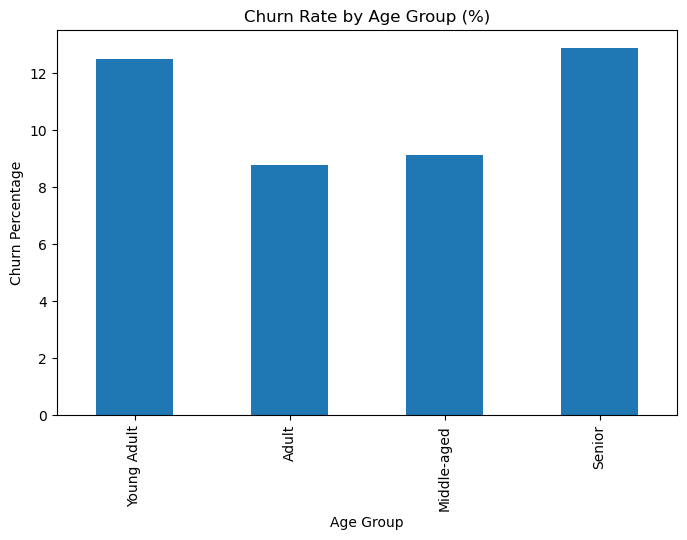

In [137]:
churn_rate['Yes'].plot(kind='bar', figsize=(8,5))

plt.title("Churn Rate by Age Group (%)")
plt.ylabel("Churn Percentage")
plt.xlabel("Age Group")

plt.show()

## Senior and Young Adult segments exhibit the highest churn rates, while Adult customers show the lowest churn, indicating stronger retention in that segment.

 ### Gender V/S Churn

In [138]:
churn_gender= pd.crosstab(df['gender'], df['churn'], normalize='index') * 100

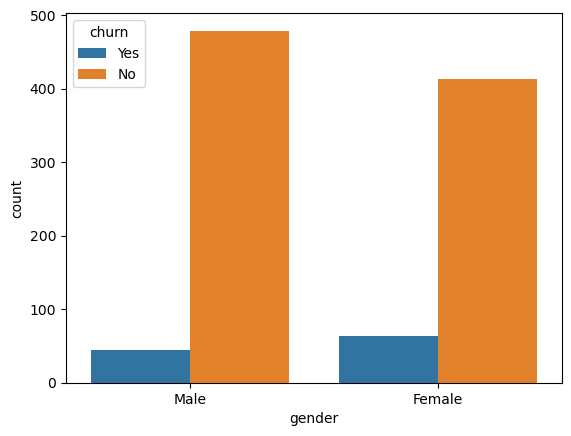

In [139]:
sns.countplot(x='gender', hue='churn', data=df)
plt.show()

## Churn rates are relatively similar across genders, indicating gender is not a strong predictor of churn.

## 2. Revenue Analysis

 ### Monthly Charges vs Churn

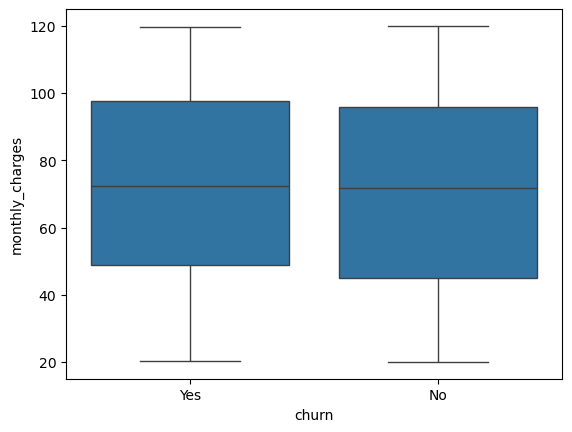

In [140]:
sns.boxplot(x='churn', y='monthly_charges', data=df)
plt.show()

 ## Customers with higher monthly charges tend to churn more → price sensitivity

 ### Revenue Loss Due to Churn

In [141]:
revenue_loss = df[df['churn']=='Yes']['monthly_charges'].sum()


In [142]:
revenue_loss

np.float64(7709.99)

## 3. CONTRACT TYPE

In [143]:
contract_churn = pd.crosstab(df['contract_type'], df['churn'], normalize='index') * 100
contract_churn

churn,No,Yes
contract_type,,
Month-to-Month,81.818182,18.181818
One Year,100.000000,0.000000
Two Year,100.000000,0.000000


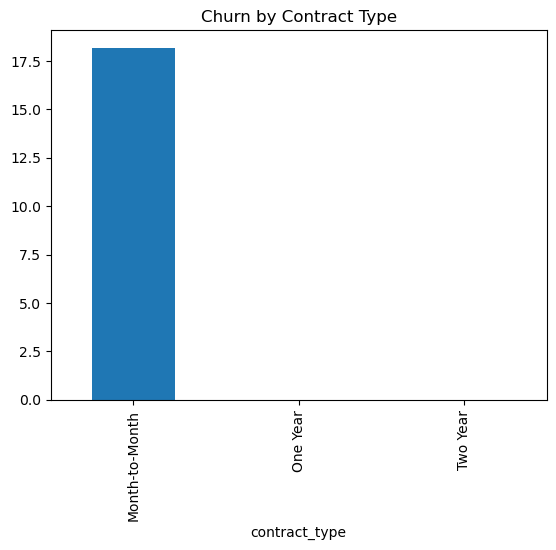

In [144]:
contract_churn['Yes'].plot(kind='bar')
plt.title("Churn by Contract Type")
plt.show()

## Month-to-Month contracts have higher churn → lack of commitment

## 4. Service Usage Analysis

### Internet Service

In [145]:
pd.crosstab(df['internet_service'], df['churn'], normalize='index') * 100

churn,No,Yes
internet_service,,
DSL,91.194969,8.805031
Fiber,88.307692,11.692308
No Internet,88.235294,11.764706


## No Internet users may churn more → higher expectations

## 5. Customer Experience

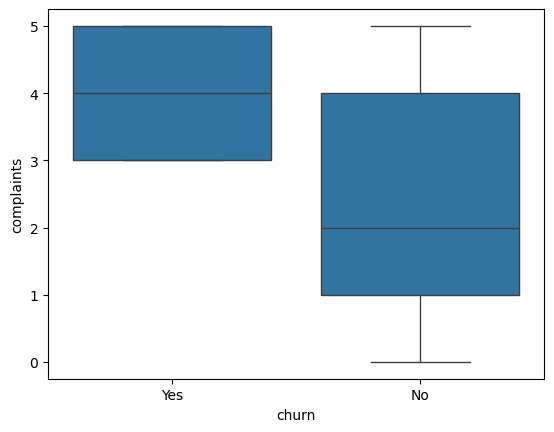

In [146]:
sns.boxplot(x='churn', y='complaints', data=df)
plt.show()

## More complaints → higher churn probability

## 6. Payment Method

In [147]:
pd.crosstab(df['payment_method'], df['churn'], normalize='index') * 100

churn,No,Yes
payment_method,,
Bank Transfer,89.743590,10.256410
Credit Card,89.028213,10.971787
UPI,88.787879,11.212121


# Statistical Validation

In [148]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['contract_type'], df['churn'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("p-value:", p)

p-value: 1.0710367100356272e-18


## Customers on different contract types exhibit significantly different churn behavior, confirming that contract type is a key driver of churn

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


X = df[['tenure', 'monthly_charges', 'complaints', 'satisfaction_score']]
y = df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.89


In [150]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
2,complaints,1.069349
1,monthly_charges,0.003620
0,tenure,-0.006643
3,satisfaction_score,-0.779238


# 📊 Business Recommendations: Customer Churn Analysis

---

## 1. 🎯 Executive Recommendation Summary

Based on the analysis, customer churn is primarily driven by:

- Month-to-month contract customers  
- High complaint frequency  
- High monthly charges  
- Lack of support services  
- High-risk age segments (Senior & Young Adult)  

👉 Therefore, the company should adopt a **targeted retention strategy** rather than a generic approach.

---

## 2. 💼 Strategic Recommendations (High Impact)

---

### 2.1 🧾 Contract Optimization Strategy (BIGGEST IMPACT 🔥)

**📌 Problem:**  
Month-to-month customers show significantly higher churn  

**💡 Recommendation:**  
Introduce incentives for long-term contracts  

**✅ Actions:**
- Offer **10–15% discount** for annual plans  
- Provide **free upgrades** for 2-year contracts  
- Enable **easy contract switching**  

**📈 Expected Outcome:**
- Increased customer retention  
- Higher customer lifetime value (CLTV)  

---

### 2.2 📞 Customer Support Enhancement

**📌 Problem:**  
- Customers without tech support churn more  
- High complaints directly linked to churn  

**💡 Recommendation:**  
Strengthen customer support infrastructure  

**✅ Actions:**
- Provide **24/7 support availability**  
- Offer **dedicated support for high-value customers**  
- Implement **SLA-based faster complaint resolution**  

**📈 Expected Outcome:**
- Reduced dissatisfaction  
- Lower churn probability  

---

### 2.3 😡 Complaint Reduction Program

**📌 Problem:**  
High complaints → High churn  

**💡 Recommendation:**  
Implement **proactive complaint management**  

**✅ Actions:**
- Identify **repeat complaint customers**  
- Introduce:
  - Priority handling  
  - Follow-up calls  
- Conduct **root cause analysis** of common issues  

**📈 Expected Outcome:**
- Improved customer trust  
- Reduced churn drivers  

---

### 2.4 😊 Customer Satisfaction Improvement

**📌 Problem:**  
Low satisfaction strongly correlates with churn  

**💡 Recommendation:**  
Focus on **customer experience improvement**  

**✅ Actions:**
- Conduct **post-service feedback surveys**  
- Offer **personalized deals for low-score customers**  
- Build **service quality monitoring dashboards**  

**📈 Expected Outcome:**
- Increased engagement  
- Better retention  

---

### 2.5 💰 Pricing & Value Strategy

**📌 Problem:**  
High monthly charges linked to churn  

**💡 Recommendation:**  
Improve **perceived value of services**  

**✅ Actions:**
- Bundle services (Internet + Support)  
- Introduce **tiered pricing plans**  
- Offer **loyalty-based discounts**  

**📈 Expected Outcome:**
- Reduced price sensitivity  
- Higher customer satisfaction  

---

## 🚀 Final Business Insight

> The analysis highlights that churn is driven by contract flexibility, service dissatisfaction, and pricing factors.  
> Implementing targeted retention strategies focused on high-risk segments can significantly reduce churn and improve long-term profitability.